## AR (Autoregressive Model)

AR model predicts future values using past values.

### Formula Idea:
Current value depends on previous values

Example:
Y(t) = c + a1*Y(t-1) + a2*Y(t-2)

- Y(t) → "Today's Value" (The Goal)
- c → "Base Value" (The Starting Point)
- a1, a2 → "Weights" (The Importance)
- Y(t−1) → "Yesterday's Value" (Lag 1)
- Y(t-2) → "Day Before Yesterday's Value" (Lag 2)

### Simple Example:
Today's temperature depends on yesterday's temperature



### Key Point:
Uses past values only

<img src="AR_model_G.png" alt="Time Series info" width="900" height="500" />





### End-to-End Flow of AR Model:

1. **Load Data**
2. **Check Stationarity** (Important for AR model)
3. **Determine Order (p)** using PACF plot
4. **Train AR Model**
5. **Make Predictions**
6. **Evaluate Model**


In [14]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## Load data

In [15]:
# Load NAB Machine Temperature dataset from online source
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(url)

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Set timestamp as the index (crucial for time series)
df.set_index('timestamp', inplace=True)

df = df[:500]
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (500, 1)
                         value
timestamp                     
2013-12-02 21:15:00  73.967322
2013-12-02 21:20:00  74.935882
2013-12-02 21:25:00  76.124162
2013-12-02 21:30:00  78.140707
2013-12-02 21:35:00  79.329836


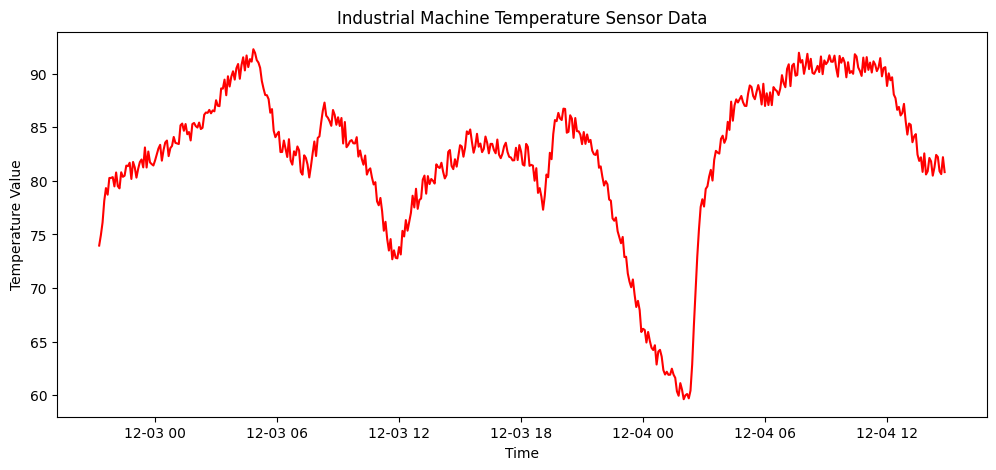

In [ ]:
# Plot the raw machine temperature data
plt.figure(figsize=(12,5))
plt.plot(df['value'], color='red')
plt.title("Industrial Machine Temperature Sensor Data")
plt.xlabel("Time")
plt.ylabel("Temperature Value")
plt.show()

# This plot tells us the data is non-stationary 

## Check Stationarity

AR model works best on **stationary** data (mean and variance should not change over time).

We use **ADF Test** to check stationarity.

In [12]:
# Check Stationarity
result = adfuller(df['value'])
print("p-value:", result[1])

# If:
# p > 0.05 → NOT stationary

# If trend or pattern changing in the Data 
#       → AR model not works directly


p-value: 0.11267746027638631


In [5]:
# Make Stationary (Differencing)
# Now data becomes stable

# log transform (variance stabilize)
df['log'] = np.log(df['value'])

# differencing
df['diff'] = df['log'].diff()

df = df.dropna()

## Determine AR Order (p) using PACF Plot

PACF (Partial Autocorrelation Function) tells us how many past lags are significant.

<Figure size 1000x500 with 0 Axes>

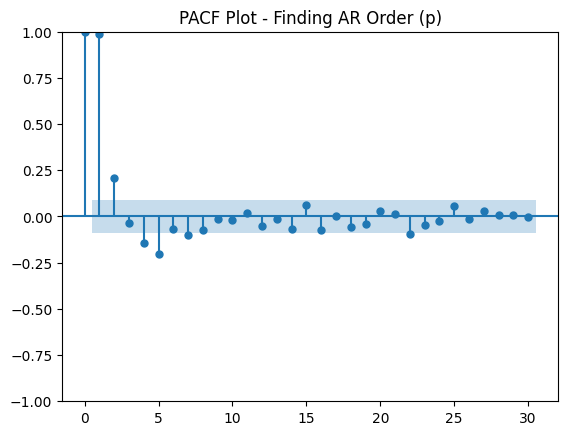

👉 Look at where PACF plot cuts off (significant spikes). That gives us value of 'p'.


In [13]:
plt.figure(figsize=(10, 5))
plot_pacf(df['value'], lags=30, title="PACF Plot - Finding AR Order (p)")
plt.show()

print("👉 Look at where PACF plot cuts off (significant spikes). That gives us value of 'p'.")

In [ ]:
# how many past values or lags is useful for prediction 

from statsmodels.tsa.ar_model import ar_select_order

# automatically select lag
sel = ar_select_order(df['diff'], maxlag=15)

print("Best lag:", sel.ar_lags)

lags = len(sel.ar_lags)


Best lag: [1, 2, 3, 4]


#### To predict next value model needs last 4 values because Best lag: [1, 2, 3, 4]

## Train-Test Split + Model Training Cell

In [ ]:
# Train-test split
train = df['diff'][:100]
test = df['diff'][100:]

# Train model
model = AutoReg(train, lags=lags)
model_fit = model.fit()

print(model_fit.params) # To pring Model coefficients (weights) 


const      0.001392
diff.L1   -0.534546
diff.L2   -0.114904
diff.L3    0.085309
diff.L4    0.167806
dtype: float64


### AR Model Parameters (Coefficients) Explained

These numbers show how the AR model makes predictions:

- **`const = 0.001392`**  
  This is the **constant** or base value. It is added to the prediction even if all previous values are zero.

- **`diff.L1 = -0.534546`**  
  This is the **most important** coefficient.  
  It shows the effect of the previous 1 time step (Lag 1).  
  The negative sign means: If the previous value was high, the next predicted value will tend to be **lower** (and vice versa).

- **`diff.L2 = -0.114904`**  
  This shows the effect of the value from 2 time steps ago (Lag 2). It has less impact than Lag 1.

- **`diff.L3 = 0.085309`**  
  This shows the effect of the value from 3 time steps ago (Lag 3).

- **`diff.L4 = 0.167806`**  
  This shows the effect of the value from 4 time steps ago (Lag 4).


## Prediction


In [ ]:

# Initialize the 'history' variable with the training data. 
# We convert it to a list so we can easily append new actual values to it as time moves forward.
history = list(train)

# Create an empty list to store all our forecasted/predicted values.
predictions = []

# Loop through each time step in the test dataset one by one.
for t in range(len(test)):
    
    #  Initialize the AutoRegressive (AR) model using the current 'history' data and the best number of past lags.
    model = AutoReg(history, lags=lags)
    
    # Train (fit) the model on the currently available history.
    model_fit = model.fit()
    
    #  Make a prediction for the very next time step. 
    # Setting both start and end to len(history) means we are asking the model to forecast exactly one step into the future.
    yhat = model_fit.predict(start=len(history), end=len(history))
    
    #  The predict function returns an array, so we take the first (and only) element (yhat[0]) 
    # and add it to our predictions list.
    predictions.append(yhat[0])
    
    #  add the actual value
    # We take the actual, real value from the test set for this time step and add it to our history.
    # This ensures that when the loop runs for the next step, the model has the most up-to-date real data to learn from.
    history.append(test.iloc[t])



## Plot Results

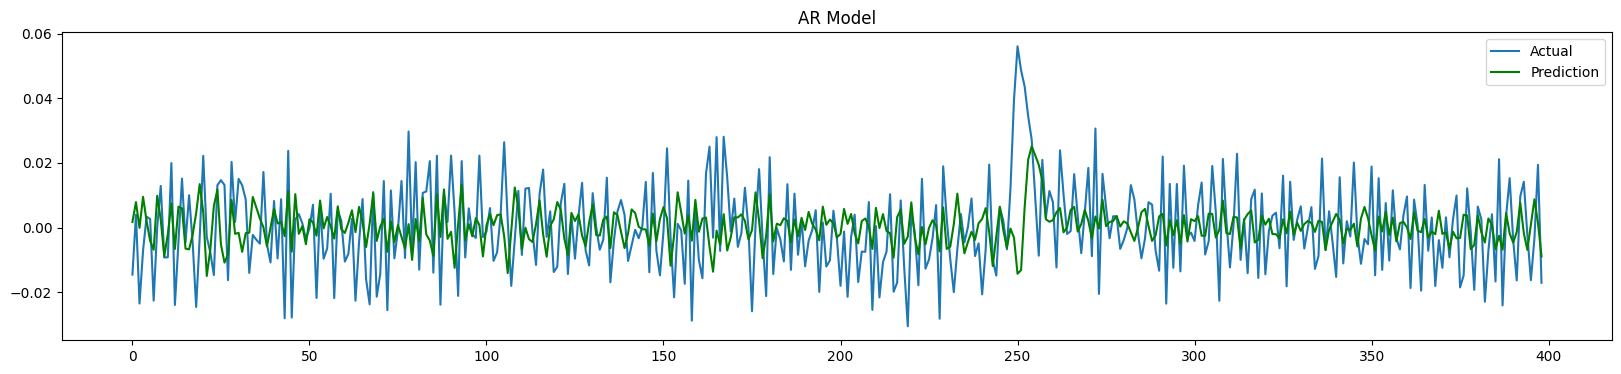

In [21]:
# Plot Results

plt.figure(figsize=(20,4))

plt.plot(test.values, label='Actual')
plt.plot(predictions, label='Prediction', color='green')

plt.legend()
plt.title("AR Model")
plt.show()


### Model Prediction Plot Analysis

This graph compares the **Actual** values (blue) with the **Predicted** values (green) on the test data.

- The predictions closely follow the actual values, showing that the AR model has learned the underlying pattern well.
- Both lines move together with similar fluctuations.
- The model successfully detected the major spike around index 250.
- Overall, this indicates a **good fit** of the AR model.

## Evaluation

In [18]:
# Evaluate Model

mse = mean_squared_error(test, predictions)
print("Improved MSE:", mse)

Improved MSE: 0.00017743078181028444


- MSE measures the average squared difference between actual and predicted values.
- **Lower MSE is better.**
- Our MSE is very small (0.000177), which indicates that the AR model is making **highly accurate predictions**.
- The model is performing well on the test data.

## End-to-End Summary of AR Model

**What we did:**

1. Loaded time series data
2. Checked if data is stationary
3. Used PACF plot to decide number of lags (`p`)
4. Trained AutoRegressive (AR) model
5. Made future predictions
6. Compared predictions with actual values
7. Evaluated using MSE



**AR Model is best when:**
- Data is stationary
- Current value strongly depends on recent past values
- No strong seasonal patterns

#### This project demonstrates **predicting machine temperature** using an **Autoregressive (AR) Model**.

#### We used real historical temperature data from an industrial machine to forecast future temperature values. The AR model was trained on differenced data, allowing it to learn patterns from past readings and predict the next temperature values.

#### The model performed well, achieving a very low **Mean Squared Error (MSE) of 0.000177**. The predictions closely matched the actual values and successfully captured sudden spikes in temperature.

### Objective:
To show how a simple yet effective time series model like AR can be used for machine temperature forecasting, which can help in early detection of potential machine issues and prevent failures.